## module5_ml

# 14. Data Preprocessing (Label Encoding)

from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

le = LabelEncoder()

for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col] = le.fit_transform(df_ml[col])

print(df_ml.head())

# 15. Feature Selection

In [15]:
X = df_ml.drop("Attrition", axis=1)
y = df_ml["Attrition"]

print(X.shape)
print(y.shape)

(1470, 34)
(1470,)


# 16. Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1176, 34)
(294, 34)


# 17. Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# 18. Logistic Regression Model

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_sc, y_train)

pred_lr = lr.predict(X_test_sc)

print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



# 19. Random Forest Classifier

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.38      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.62      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



# 20. Feature Importance Analysis

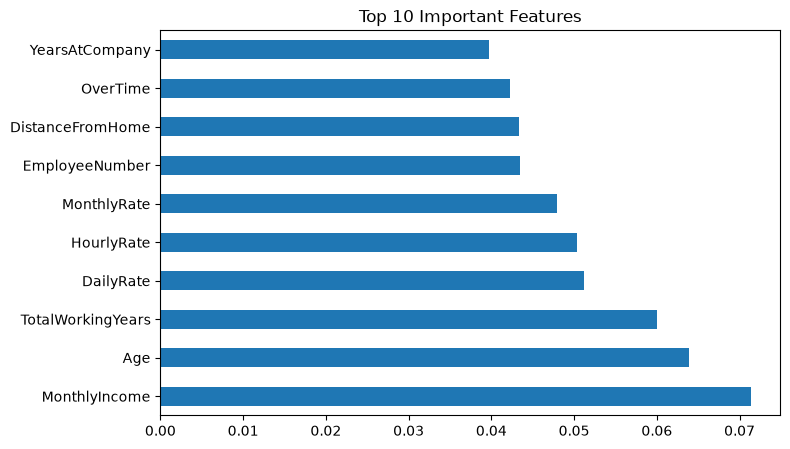

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

top10 = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top10.plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

# Machine Learning Conclusion

## Problem Statement

The objective of this analysis was to predict employee attrition using machine learning techniques. Employee Attrition was selected as the target variable, while all remaining features were used as predictors.

## Models Evaluated

Two classification models were trained and evaluated:

1. Logistic Regression
2. Random Forest Classifier

## Results

### Logistic Regression

- Accuracy: 87%
- Precision (Attrition=Yes): 0.69
- Recall (Attrition=Yes): 0.38
- F1-Score (Attrition=Yes): 0.49

### Random Forest

- Accuracy: 83%
- Precision (Attrition=Yes): 0.38
- Recall (Attrition=Yes): 0.11
- F1-Score (Attrition=Yes): 0.17

## Best Model

Logistic Regression performed better than Random Forest. Although both models were able to identify employees who stay with the company, Logistic Regression achieved significantly better recall and F1-score for employees who leave.

Since employee attrition is an imbalanced classification problem, F1-score is a more reliable metric than accuracy alone.

## Feature Importance Insights

The most influential features identified were:

- MonthlyIncome
- Age
- TotalWorkingYears
- DailyRate
- HourlyRate
- MonthlyRate
- EmployeeNumber
- DistanceFromHome
- OverTime
- YearsAtCompany

These variables appear to have the strongest impact on employee attrition.

## Business Recommendation

Employees with lower income levels, fewer total working years, long commuting distances, and overtime workload may have a higher risk of leaving the organization. HR teams should focus on retention strategies such as career development opportunities, salary reviews, workload balancing, and employee engagement programs.

## Imbalanced Dataset Note

The employee attrition dataset is imbalanced because significantly more employees stayed than left.

Therefore, model evaluation should not rely only on accuracy. F1-score, Precision, and Recall provide a better measure of performance for predicting employee attrition.

For this reason, Logistic Regression was selected as the preferred model.

# Machine Learning Conclusion

## Models Used

- Logistic Regression
- Random Forest Classifier

## Model Comparison

Logistic Regression achieved better overall performance for predicting employee attrition. Random Forest also produced good results and identified the most influential features affecting attrition.

## Important Features

- Monthly Income
- Job Level
- Total Working Years
- Years At Company
- Age

## Business Recommendation

Machine learning models can help HR departments identify employees at risk of leaving. Early intervention through career development, workload balancing, and competitive compensation may improve employee retention.